<a href="https://colab.research.google.com/github/Saibhossain/Agentic-framework/blob/main/Research_Review_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# setup

In [1]:
!pip install -U langgraph langchain langchain-core langchain-openai serpapi pydantic
!pip install langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.5 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.4
    Uninstalling pydantic_core-2.41.4:
      Successfully uninstalled pydantic_core-2.41.4
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.3
    Uninstalling pydantic-2.12.3:
      Successfully uninstalled pydantic-2.12.3
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.23
   

# search web tools



## Install requirements

In [43]:
!pip uninstall -y serpapi google-search-results
!pip install -U google-search-results==2.4.2

Found existing installation: google_search_results 2.4.2
Uninstalling google_search_results-2.4.2:
  Successfully uninstalled google_search_results-2.4.2
  Using cached google_search_results-2.4.2-py3-none-any.whl


### Test code

In [45]:
import serpapi
print("serpapi file:", serpapi.__file__)
print("has GoogleSearch:", hasattr(serpapi, "GoogleSearch"))
print("module attrs sample:", [x for x in dir(serpapi) if "Google" in x or "search" in x.lower()][:20])

serpapi file: /usr/local/lib/python3.12/dist-packages/serpapi/__init__.py
has GoogleSearch: False
module attrs sample: ['SearchIDNotProvided', 'search', 'search_archive']


In [46]:
from google.colab import userdata
import serpapi

key = userdata.get("SERP_API_Key")

params = {
    "engine": "google_scholar",
    "q": "LangChain agent architecture paper",
    "api_key": key,
    "hl": "en",
    "num": 5,
}

results = serpapi.search(params)

for i, paper in enumerate(results.get("organic_results", []), 1):
    print(f"{i}. {paper.get('title')}")
    print("   Link:", paper.get("link"))
    print("   Snippet:", paper.get("snippet"))
    print("-" * 80)

1. Langchain & langgraph in production: Architectures for multi-agent llm systems
   Link: http://datalensjourna.com/index.php/JDDI/article/view/35
   Snippet: … This paper explores the architectural underpinnings of LangChain and LangGraph, … , and communication of autonomous LLM agents. By integrating symbolic reasoning with generative …
--------------------------------------------------------------------------------
2. LangGraph vs LangChain: Which Framework Is Best for AI Agents?
   Link: https://sinojournals.com/index.php/mvjms/article/view/10
   Snippet: … This paper aims to dissect the nuances of LangGraph versus … that LangChain favors ease and speed, while LangGraph prioritizes depth and durability in AI agent architectures. …
--------------------------------------------------------------------------------
3. LangChain vs. LangGraph vs. LangSmith: Taxonomies of agentic AI toolchains for end-to-end orchestration
   Link: https://www.techrxiv.org/doi/full/10.36227/techrxiv.17569

# scholarGate Agent

#### A human-supervised research agent that can:

* search Google Scholar
* do web search when needed
* find related papers
* explain a paper
* pause for human approval before every search or explanation step

This design fits LangGraph well because LangGraph supports interrupts, durable execution, and human-in-the-loop review, while tools are first-class callables that agents can invoke dynamically.



```
      User Request
        ↓
      Planner Node
        ↓
      Human Approval Gate  ← interrupt before any action
        ↓
      Search Node
        ├─ Google Scholar Tool
        ├─ Web Search Tool
        └─ Related Paper Tool
        ↓
      Human Approval Gate  ← interrupt before explanation
        ↓
      Paper Explanation Node
        ↓
      Final Answer

```

### import

In [2]:
# ScholarGate Agent

""" Human-supervised research search + paper explainer with LangGraph
    A human-supervised research agent that can:

    search Google Scholar
    do web search when needed
    find related papers
    explain a paper
    pause for human approval before every search or explanation step

This design fits LangGraph well because LangGraph supports interrupts, durable execution, and human-in-the-loop review, while tools are first-class callables that agents can invoke dynamically.
"""

from __future__ import annotations

import json
from typing import TypedDict, Optional, Literal, List, Dict, Any

import serpapi

from pydantic import BaseModel, Field

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

###  1. CONFIG

In [3]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from google.colab import userdata
import operator # Import the operator module

userdata.get('google_api')
load_dotenv()

SERP_API_KEY = userdata.get("SERP_API_Key") # search web

# Get the API key from Colab's user data and set it as an environment variable
os.environ['GOOGLE_API_KEY'] = userdata.get('google_api')

llm = init_chat_model("google_genai:gemini-2.5-flash-lite")

###  2. TOOLS

In [5]:
# ============================================================
# 2) TOOLS
# ============================================================

@tool
def google_scholar_search(query: str, num_results: int = 5) -> str:
    """Search Google Scholar for academic papers."""
    params = {
        "engine": "google_scholar",
        "q": query,
        "api_key": SERP_API_KEY,
        "hl": "en",
        "num": num_results,
    }
    results = serpapi.search(params)
    papers = results.get("organic_results", [])

    if not papers:
        return json.dumps({"query": query, "results": []}, ensure_ascii=False)

    cleaned = []
    for p in papers:
        cleaned.append({
            "title": p.get("title"),
            "link": p.get("link"),
            "snippet": p.get("snippet"),
            "publication_info": p.get("publication_info"),
            "inline_links": p.get("inline_links"),
        })

    return json.dumps({"query": query, "results": cleaned}, ensure_ascii=False, indent=2)


@tool
def web_search(query: str, num_results: int = 5) -> str:
    """Search the general web for pages, blogs, docs, and paper landing pages."""
    params = {
        "engine": "google",
        "q": query,
        "api_key": SERP_API_KEY,
        "hl": "en",
        "num": num_results,
    }
    results = serpapi.search(params)
    organic = results.get("organic_results", [])

    cleaned = []
    for r in organic:
        cleaned.append({
            "title": r.get("title"),
            "link": r.get("link"),
            "snippet": r.get("snippet"),
        })

    return json.dumps({"query": query, "results": cleaned}, ensure_ascii=False, indent=2)


@tool
def related_paper_search(seed_title: str, num_results: int = 5) -> str:
    """Find papers related to a seed paper title using Google Scholar."""
    params = {
        "engine": "google_scholar",
        "q": f'"{seed_title}" related work OR similar paper OR survey',
        "api_key": SERP_API_KEY,
        "hl": "en",
        "num": num_results,
    }
    results = serpapi.search(params)
    papers = results.get("organic_results", [])

    cleaned = []
    for p in papers:
        cleaned.append({
            "title": p.get("title"),
            "link": p.get("link"),
            "snippet": p.get("snippet"),
            "publication_info": p.get("publication_info"),
        })

    return json.dumps(
        {"seed_title": seed_title, "results": cleaned},
        ensure_ascii=False,
        indent=2
    )


TOOLS = {
    "google_scholar_search": google_scholar_search,
    "web_search": web_search,
    "related_paper_search": related_paper_search,
}

### 3.State

In [8]:
# ============================================================
# 3) STATE
# ============================================================

class AgentState(TypedDict, total=False):
    user_request: str
    mode: Literal["find_papers", "explain_paper", "find_related_papers"]
    plan: Dict[str, Any]
    tool_name: str
    tool_args: Dict[str, Any]
    tool_result: str
    final_answer: str


# ============================================================
# 4) PLANNER OUTPUT SCHEMA
# ============================================================

class PlanOutput(BaseModel):
    mode: Literal["find_papers", "explain_paper", "find_related_papers"] = Field(
        description="Task type"
    )
    tool_name: Literal["google_scholar_search", "web_search", "related_paper_search"] = Field(
        description="Primary tool to use first"
    )
    tool_args: Dict[str, Any] = Field(description="Arguments for the primary tool")
    explanation_prompt: str = Field(
        description="Prompt to use later if explanation is requested"
    )


planner_llm = llm.with_structured_output(PlanOutput)

### NODES

In [12]:
# ============================================================
# 5) NODES
# ============================================================

def planner_node(state: AgentState) -> AgentState:
    user_request = state["user_request"]

    system = SystemMessage(content=(
        "You are a research workflow planner.\n"
        "Choose the best first tool.\n"
        "Rules:\n"
        "- Use google_scholar_search for academic paper discovery.\n"
        "- Use web_search if the user asks for docs, blog explainers, project pages, or broader context.\n"
        "- Use related_paper_search if the user explicitly wants related papers to a named paper.\n"
        "- If the user asks to explain a paper, first search for it with google_scholar_search.\n"
        "- Return compact structured output."
    ))
    human = HumanMessage(content=user_request)

    plan = planner_llm.invoke([system, human])

    return {
        "mode": plan.mode,
        "plan": plan.model_dump(),
        "tool_name": plan.tool_name,
        "tool_args": plan.tool_args,
    }


def approval_before_search_node(state: AgentState) -> AgentState:
    payload = {
        "stage": "before_search",
        "message": "Approve or edit the planned search action before running any tool.",
        "planned_mode": state["mode"],
        "tool_name": state["tool_name"],
        "tool_args": state["tool_args"],
    }

    decision = interrupt(payload)
    # expected resume payload examples:
    # {"action": "approve"}
    # {"action": "edit", "tool_name": "...", "tool_args": {...}}
    # {"action": "reject", "reason": "..."}

    action = decision.get("action", "approve")

    if action == "reject":
        return {"final_answer": f"Operation stopped by human reviewer: {decision.get('reason', 'No reason provided.')}"}

    if action == "edit":
        return {
            "tool_name": decision.get("tool_name", state["tool_name"]),
            "tool_args": decision.get("tool_args", state["tool_args"]),
        }

    return {}


def run_search_tool_node(state: AgentState) -> AgentState:
    if state.get("final_answer"):
        return {}

    tool_name = state["tool_name"]
    tool_args = state["tool_args"]

    if tool_name not in TOOLS:
        return {"final_answer": f"Unknown tool: {tool_name}"}

    result = TOOLS[tool_name].invoke(tool_args)
    return {"tool_result": result}


def approval_before_explain_node(state: AgentState) -> AgentState:
    if state.get("final_answer"):
        return {}

    payload = {
        "stage": "before_explain",
        "message": "Approve or edit the explanation step before the model explains results.",
        "mode": state["mode"],
        "tool_name": state["tool_name"],
        "tool_args": state["tool_args"],
        "tool_result_preview": state["tool_result"][:1500],
    }

    decision = interrupt(payload)
    # expected:
    # {"action": "approve"}
    # {"action": "reject", "reason": "..."}
    # {"action": "edit", "instruction": "Explain in simpler words"}

    action = decision.get("action", "approve")

    if action == "reject":
        return {"final_answer": f"Explanation step stopped by human reviewer: {decision.get('reason', 'No reason provided.')}"}

    if action == "edit":
        edited_instruction = decision.get("instruction", "")
        return {"plan": {**state["plan"], "human_edit_instruction": edited_instruction}}

    return {}


def explain_results_node(state: AgentState) -> AgentState:
    if state.get("final_answer"):
        return {}

    mode = state["mode"]
    user_request = state["user_request"]
    tool_result = state["tool_result"]
    human_edit_instruction = state.get("plan", {}).get("human_edit_instruction", "")

    system_text = (
        "You are ScholarGate, a research assistant.\n"
        "Use the tool results only.\n"
        "Be careful, concise, and structured.\n"
        "If results look low quality, say so explicitly.\n"
    )

    if mode == "find_papers":
        task_text = (
            "Summarize the found papers.\n"
            "For each one, mention title, why it seems relevant, and any red flags.\n"
            "At the end, recommend the top 3."
        )
    elif mode == "find_related_papers":
        task_text = (
            "Summarize the related papers.\n"
            "Explain how they appear related to the seed paper.\n"
            "Group similar directions if possible."
        )
    else:
        task_text = (
            "Explain the paper search results to the user.\n"
            "If multiple papers were found, identify the most likely target.\n"
            "Then explain the paper in simple technical language: problem, method, contribution, limitation."
        )

    if human_edit_instruction:
        task_text += f"\nAdditional human instruction: {human_edit_instruction}"

    messages = [
        SystemMessage(content=system_text),
        HumanMessage(content=(
            f"Original user request:\n{user_request}\n\n"
            f"Tool results:\n{tool_result}\n\n"
            f"Task:\n{task_text}"
        ))
    ]

    answer = llm.invoke(messages)
    return {"final_answer": answer.content}


# ============================================================
# 6) ROUTING
# ============================================================

def route_after_search_approval(state: AgentState) -> str:
    if state.get("final_answer"):
        return "end"
    return "run_search_tool"


def route_after_explain_approval(state: AgentState) -> str:
    if state.get("final_answer"):
        return "end"
    return "explain_results"

### BUILD GRAPH

In [13]:
# ============================================================
# 7) BUILD GRAPH
# ============================================================

graph_builder = StateGraph(AgentState)

# Add nodes
graph_builder.add_node("planner", planner_node)
graph_builder.add_node("approval_before_search", approval_before_search_node)
graph_builder.add_node("run_search_tool", run_search_tool_node)
graph_builder.add_node("approval_before_explain", approval_before_explain_node)
graph_builder.add_node("explain_results", explain_results_node)

# Entry
graph_builder.set_entry_point("planner")

# Normal edges
graph_builder.add_edge("planner", "approval_before_search")
graph_builder.add_edge("run_search_tool", "approval_before_explain")
graph_builder.add_edge("explain_results", END)

# Conditional routing after search approval
graph_builder.add_conditional_edges(
    "approval_before_search",
    route_after_search_approval,
    {
        "run_search_tool": "run_search_tool",
        "end": END,
    },
)

# Conditional routing after explain approval
graph_builder.add_conditional_edges(
    "approval_before_explain",
    route_after_explain_approval,
    {
        "explain_results": "explain_results",
        "end": END,
    },
)

# Compile
checkpointer = MemorySaver()
app = graph_builder.compile(checkpointer=checkpointer)

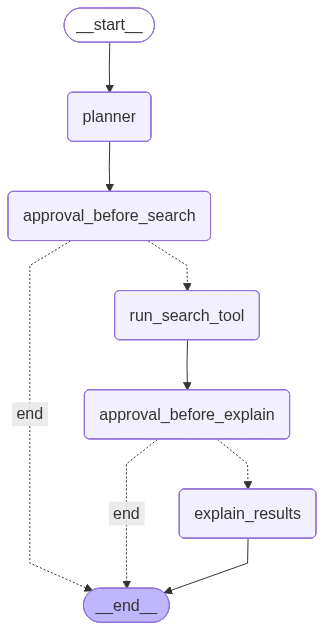

In [14]:
app

### HELPER FUNCTIONS

In [15]:
# ============================================================
# 8) HELPER FUNCTIONS
# ============================================================

def run_agent(user_request: str, thread_id: str = "scholar-1"):
    """
    Starts the graph and will pause at the first interrupt.
    """
    config = {"configurable": {"thread_id": thread_id}}
    return app.invoke({"user_request": user_request}, config=config)


def resume_agent(resume_payload: dict, thread_id: str = "scholar-1"):
    """
    Resumes after an interrupt.
    """
    config = {"configurable": {"thread_id": thread_id}}
    return app.invoke(Command(resume=resume_payload), config=config)

# ScholarGate Agent Test

In [18]:
out = run_agent("Find recent papers about LangGraph multi-agent architecture")

> RUN

In [19]:
out

{'user_request': 'Find recent papers about LangGraph multi-agent architecture',
 'mode': 'find_papers',
 'plan': {'mode': 'find_papers',
  'tool_name': 'google_scholar_search',
  'tool_args': {'query': 'LangGraph multi-agent architecture',
   'sort_by': 'date'},
  'explanation_prompt': "Summarize the key aspects of LangGraph's multi-agent architecture based on the provided research papers."},
 'tool_name': 'google_scholar_search',
 'tool_args': {'query': 'LangGraph multi-agent architecture',
  'sort_by': 'date'},
 '__interrupt__': [Interrupt(value={'stage': 'before_search', 'message': 'Approve or edit the planned search action before running any tool.', 'planned_mode': 'find_papers', 'tool_name': 'google_scholar_search', 'tool_args': {'query': 'LangGraph multi-agent architecture', 'sort_by': 'date'}}, id='6085adc6a537ce084edce604107dd8c7')]}

#### Approve the search

In [20]:
out = resume_agent({"action": "approve"})

In [21]:
out

{'user_request': 'Find recent papers about LangGraph multi-agent architecture',
 'mode': 'find_papers',
 'plan': {'mode': 'find_papers',
  'tool_name': 'google_scholar_search',
  'tool_args': {'query': 'LangGraph multi-agent architecture',
   'sort_by': 'date'},
  'explanation_prompt': "Summarize the key aspects of LangGraph's multi-agent architecture based on the provided research papers."},
 'tool_name': 'google_scholar_search',
 'tool_args': {'query': 'LangGraph multi-agent architecture',
  'sort_by': 'date'},
 'tool_result': '{\n  "query": "LangGraph multi-agent architecture",\n  "results": [\n    {\n      "title": "Langchain & langgraph in production: Architectures for multi-agent llm systems",\n      "link": "http://datalensjourna.com/index.php/JDDI/article/view/35",\n      "snippet": "… LangChain and LangGraph have emerged as pioneering frameworks … multi-agent systems efficiently. This paper explores the architectural underpinnings of LangChain and LangGraph, …",\n      "public

In [24]:
print(out["plan"])

{'mode': 'find_papers', 'tool_name': 'google_scholar_search', 'tool_args': {'query': 'LangGraph multi-agent architecture', 'sort_by': 'date'}, 'explanation_prompt': "Summarize the key aspects of LangGraph's multi-agent architecture based on the provided research papers."}


In [26]:
out['plan']

{'mode': 'find_papers',
 'tool_name': 'google_scholar_search',
 'tool_args': {'query': 'LangGraph multi-agent architecture',
  'sort_by': 'date'},
 'explanation_prompt': "Summarize the key aspects of LangGraph's multi-agent architecture based on the provided research papers."}

In [29]:
out['tool_result']

'{\n  "query": "LangGraph multi-agent architecture",\n  "results": [\n    {\n      "title": "Langchain & langgraph in production: Architectures for multi-agent llm systems",\n      "link": "http://datalensjourna.com/index.php/JDDI/article/view/35",\n      "snippet": "… LangChain and LangGraph have emerged as pioneering frameworks … multi-agent systems efficiently. This paper explores the architectural underpinnings of LangChain and LangGraph, …",\n      "publication_info": {\n        "summary": "K Pelluru - Journal of Data and Digital Innovation (JDDI), 2025 - datalensjourna.com",\n        "authors": [\n          {\n            "name": "K Pelluru",\n            "link": "https://scholar.google.com/citations?user=NkzMuiwAAAAJ&hl=en&num=5&oi=sra",\n            "author_id": "NkzMuiwAAAAJ",\n            "serpapi_scholar_link": "https://serpapi.com/search.json?author_id=NkzMuiwAAAAJ&engine=google_scholar_author&hl=en"\n          }\n        ]\n      },\n      "inline_links": {\n        "serpa

In [28]:
out['plan']['explanation_prompt']

"Summarize the key aspects of LangGraph's multi-agent architecture based on the provided research papers."

In [30]:
# Approve explanation
out = resume_agent({"action": "approve"})

In [31]:
out

{'user_request': 'Find recent papers about LangGraph multi-agent architecture',
 'mode': 'find_papers',
 'plan': {'mode': 'find_papers',
  'tool_name': 'google_scholar_search',
  'tool_args': {'query': 'LangGraph multi-agent architecture',
   'sort_by': 'date'},
  'explanation_prompt': "Summarize the key aspects of LangGraph's multi-agent architecture based on the provided research papers."},
 'tool_name': 'google_scholar_search',
 'tool_args': {'query': 'LangGraph multi-agent architecture',
  'sort_by': 'date'},
 'tool_result': '{\n  "query": "LangGraph multi-agent architecture",\n  "results": [\n    {\n      "title": "Langchain & langgraph in production: Architectures for multi-agent llm systems",\n      "link": "http://datalensjourna.com/index.php/JDDI/article/view/35",\n      "snippet": "… LangChain and LangGraph have emerged as pioneering frameworks … multi-agent systems efficiently. This paper explores the architectural underpinnings of LangChain and LangGraph, …",\n      "public

In [32]:
out['final_answer']

"Here's a summary of the papers found on LangGraph multi-agent architecture:\n\n**1. Langchain & langgraph in production: Architectures for multi-agent llm systems**\n*   **Relevance:** This paper appears highly relevant as it directly discusses the architectural underpinnings of LangChain and LangGraph for multi-agent systems. It is published in the Journal of Data and Digital Innovation in 2025.\n*   **Red Flags:** None apparent from the snippet.\n\n**2. LangGraph vs LangChain: Which Framework Is Best for AI Agents?**\n*   **Relevance:** This paper is relevant as it compares LangGraph and LangChain, specifically addressing their suitability for AI agents, including multi-agent setups. It highlights LangGraph's resilience for agents that need to adapt or recover from failures. Published in MetaVision Journal of Multidisciplinary Studies in 2024.\n*   **Red Flags:** None apparent from the snippet.\n\n**3. Exploration of llm multi-agent application implementation based on langgraph+ cre

## Example: edit before search

In [33]:
out = run_agent("Explain the paper LangGraph vs LangChain: Which Framework Is Best for AI Agents? and find related papers")

In [34]:
out

{'user_request': 'Explain the paper LangGraph vs LangChain: Which Framework Is Best for AI Agents? and find related papers',
 'mode': 'explain_paper',
 'plan': {'mode': 'explain_paper',
  'tool_name': 'google_scholar_search',
  'tool_args': {'query': 'LangGraph vs LangChain: Which Framework Is Best for AI Agents?'},
  'explanation_prompt': 'Explain the paper LangGraph vs LangChain: Which Framework Is Best for AI Agents?'},
 'tool_name': 'google_scholar_search',
 'tool_args': {'query': 'LangGraph vs LangChain: Which Framework Is Best for AI Agents?'},
 'tool_result': '{\n  "query": "LangGraph multi-agent architecture",\n  "results": [\n    {\n      "title": "Langchain & langgraph in production: Architectures for multi-agent llm systems",\n      "link": "http://datalensjourna.com/index.php/JDDI/article/view/35",\n      "snippet": "… LangChain and LangGraph have emerged as pioneering frameworks … multi-agent systems efficiently. This paper explores the architectural underpinnings of LangC

In [35]:
out ['__interrupt__']

[Interrupt(value={'stage': 'before_search', 'message': 'Approve or edit the planned search action before running any tool.', 'planned_mode': 'explain_paper', 'tool_name': 'google_scholar_search', 'tool_args': {'query': 'LangGraph vs LangChain: Which Framework Is Best for AI Agents?'}}, id='06d18fda8a6ee3f4b764a6bf4469314a')]

In [36]:
# Then edit the search plan:

out = resume_agent({
    "action": "edit",
    "tool_name": "google_scholar_search",
    "tool_args": {
        "query": "GraphMASAL",
        "num_results": 7
    }
})

In [37]:
out

{'user_request': 'Explain the paper LangGraph vs LangChain: Which Framework Is Best for AI Agents? and find related papers',
 'mode': 'explain_paper',
 'plan': {'mode': 'explain_paper',
  'tool_name': 'google_scholar_search',
  'tool_args': {'query': 'LangGraph vs LangChain: Which Framework Is Best for AI Agents?'},
  'explanation_prompt': 'Explain the paper LangGraph vs LangChain: Which Framework Is Best for AI Agents?'},
 'tool_name': 'google_scholar_search',
 'tool_args': {'query': 'GraphMASAL', 'num_results': 7},
 'tool_result': '{\n  "query": "LangGraph multi-agent architecture",\n  "results": [\n    {\n      "title": "Langchain & langgraph in production: Architectures for multi-agent llm systems",\n      "link": "http://datalensjourna.com/index.php/JDDI/article/view/35",\n      "snippet": "… LangChain and LangGraph have emerged as pioneering frameworks … multi-agent systems efficiently. This paper explores the architectural underpinnings of LangChain and LangGraph, …",\n      "pu

In [38]:
out = resume_agent({
    "action": "edit",
    "instruction": "Explain in simple English for an undergraduate AI student."
})

In [39]:
out['final_answer']

"Here's a summary of the papers found on LangGraph multi-agent architecture:\n\n**1. Langchain & langgraph in production: Architectures for multi-agent llm systems**\n*   **Relevance:** This paper appears highly relevant as it directly discusses the architectural underpinnings of LangChain and LangGraph for multi-agent systems. It is published in the Journal of Data and Digital Innovation in 2025.\n*   **Red Flags:** None apparent from the snippet.\n\n**2. LangGraph vs LangChain: Which Framework Is Best for AI Agents?**\n*   **Relevance:** This paper is relevant as it compares LangGraph and LangChain, specifically addressing their suitability for AI agents, including multi-agent setups. It highlights LangGraph's resilience for agents that need to adapt or recover from failures. Published in MetaVision Journal of Multidisciplinary Studies in 2024.\n*   **Red Flags:** None apparent from the snippet.\n\n**3. Exploration of llm multi-agent application implementation based on langgraph+ cre